# Perceptron

**INDE 577 / CMOR 438 — Rice University**  
**Instructor:** Randy R. Davila, PhD

---

## Overview

The **Perceptron** is the oldest and simplest form of a neural network — a single neuron. Invented by Frank Rosenblatt in 1958, it is the foundation of modern deep learning.

## Mathematical Background

### Model

Given input $\mathbf{x} \in \mathbb{R}^d$, weights $\mathbf{w} \in \mathbb{R}^d$, and bias $b$:

$$z = \mathbf{w}^T \mathbf{x} + b$$

$$\hat{y} = \text{step}(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

### Learning Rule (Online Update)

For each misclassified sample $(\mathbf{x}_i, y_i)$:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \cdot (y_i - \hat{y}_i) \cdot \mathbf{x}_i$$

$$b \leftarrow b + \eta \cdot (y_i - \hat{y}_i)$$

where $\eta$ is the learning rate.

### Convergence Theorem

If the data is **linearly separable**, the Perceptron algorithm is guaranteed to converge in a finite number of steps.

**Limitation**: If data is NOT linearly separable, it will never converge (the motivation for multi-layer networks).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification, make_circles
import warnings
warnings.filterwarnings('ignore')

from rice_ml import Perceptron
from rice_ml.processing.preprocessing import StandardScaler, train_test_split
from rice_ml.processing.metrics import accuracy_score, confusion_matrix

print("Libraries loaded!")
np.random.seed(42)

Libraries loaded!


## 1. Linearly Separable Data — Perceptron Convergence

In [2]:
# Generate linearly separable data
X_lin, y_lin = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    random_state=1, n_clusters_per_class=1, class_sep=2.0
)

scaler = StandardScaler()
X_lin_s = scaler.fit_transform(X_lin)

# Train
p = Perceptron(learning_rate=0.1, n_iterations=50)
p.fit(X_lin_s, y_lin)

print(f"Final training accuracy: {accuracy_score(y_lin, p.predict(X_lin_s)):.4f}")
print(f"Total misclassifications over epochs: {sum(p.errors_)}")

Final training accuracy: 0.9700
Total misclassifications over epochs: 435


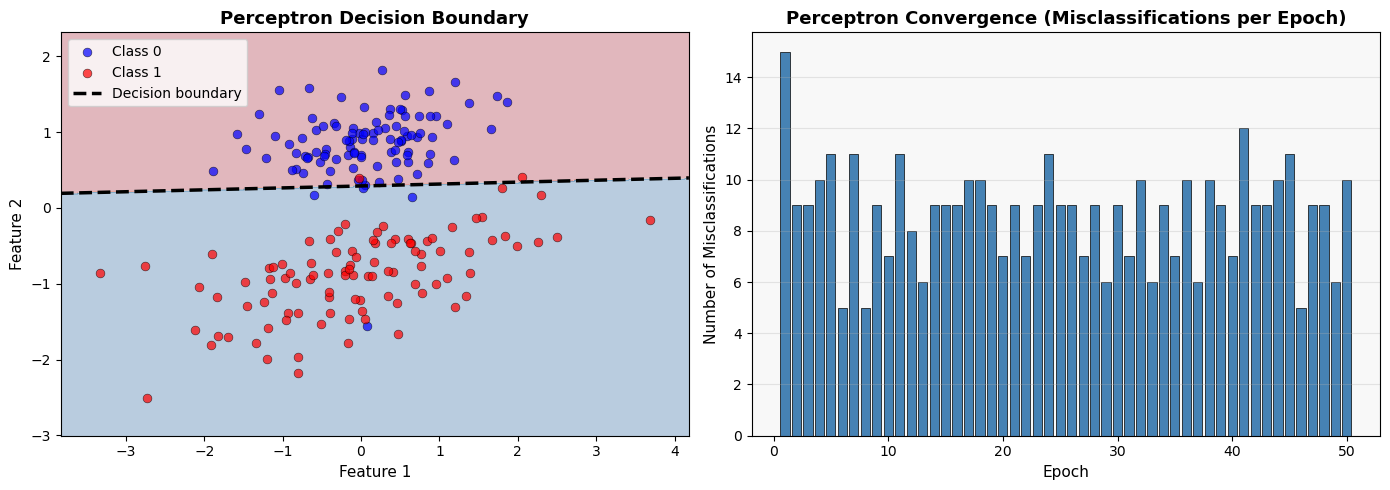

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision boundary
ax = axes[0]
x_min, x_max = X_lin_s[:, 0].min() - 0.5, X_lin_s[:, 0].max() + 0.5
y_min, y_max = X_lin_s[:, 1].min() - 0.5, X_lin_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = p.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
ax.scatter(X_lin_s[y_lin == 0, 0], X_lin_s[y_lin == 0, 1], c='blue', s=40, alpha=0.7, edgecolors='k', lw=0.4, label='Class 0')
ax.scatter(X_lin_s[y_lin == 1, 0], X_lin_s[y_lin == 1, 1], c='red', s=40, alpha=0.7, edgecolors='k', lw=0.4, label='Class 1')

# Decision boundary line
w = p.weights_
b = p.bias_
x_line = np.linspace(x_min, x_max, 100)
if abs(w[1]) > 1e-8:
    y_line = -(w[0] * x_line + b) / w[1]
    ax.plot(x_line, y_line, 'k--', linewidth=2.5, label='Decision boundary')

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.set_title('Perceptron Decision Boundary', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Errors per epoch
ax2 = axes[1]
ax2.bar(range(1, len(p.errors_) + 1), p.errors_, color='steelblue', edgecolor='k', linewidth=0.5)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Number of Misclassifications', fontsize=11)
ax2.set_title('Perceptron Convergence (Misclassifications per Epoch)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('figures/perceptron_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. XOR Problem — Limitation of the Perceptron

The Perceptron cannot learn the XOR function because it is NOT linearly separable. This fundamental limitation, highlighted by Minsky & Papert (1969), sparked the interest in multi-layer networks.

In [4]:
# XOR data
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])

p_xor = Perceptron(learning_rate=0.1, n_iterations=100)
p_xor.fit(X_xor, y_xor)
y_pred_xor = p_xor.predict(X_xor)

print("XOR Truth Table:")
print(f"{'Input':^12} {'True':^6} {'Predicted':^10}")
print("-" * 30)
for xi, yt, yp in zip(X_xor, y_xor, y_pred_xor):
    correct = '✓' if yt == yp else '✗'
    print(f"{str(xi.astype(int)):^12} {yt:^6} {yp:^10} {correct}")
print(f"\nAccuracy: {accuracy_score(y_xor, y_pred_xor):.2f} (cannot do better than 0.75 without non-linearity)")

XOR Truth Table:
   Input      True  Predicted 
------------------------------
   [0 0]       0        1      ✗
   [0 1]       1        1      ✓
   [1 0]       1        0      ✗
   [1 1]       0        0      ✓

Accuracy: 0.50 (cannot do better than 0.75 without non-linearity)


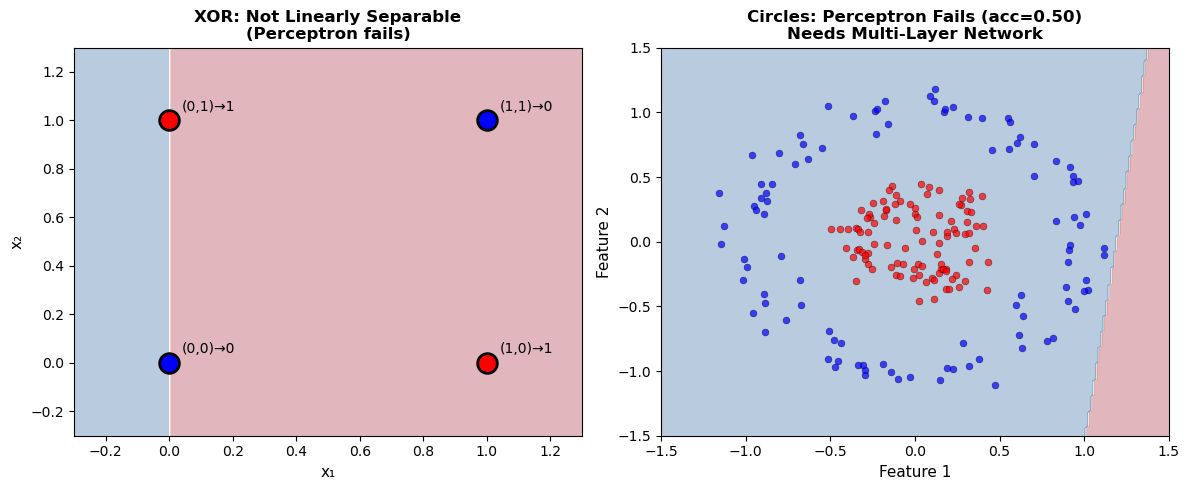

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# XOR plot
ax = axes[0]
xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
Z_xor = p_xor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z_xor, alpha=0.3, cmap='RdBu')
colors_xor = ['blue', 'blue', 'blue', 'red']
labels_xor = ['(0,0)→0', '(0,1)→1', '(1,0)→1', '(1,1)→0']
for xi, yi, col, lbl in zip(X_xor, y_xor, ['blue', 'red', 'red', 'blue'], labels_xor):
    ax.scatter(xi[0], xi[1], c=col, s=200, zorder=5, edgecolors='k', linewidths=2)
    ax.annotate(lbl, xi + np.array([0.04, 0.04]), fontsize=10)
ax.set_title('XOR: Not Linearly Separable\n(Perceptron fails)', fontsize=12, fontweight='bold')
ax.set_xlabel('x₁', fontsize=11); ax.set_ylabel('x₂', fontsize=11)

# Non-linearly separable (circles)
X_circ, y_circ = make_circles(n_samples=200, noise=0.1, factor=0.3, random_state=42)
p_circ = Perceptron(learning_rate=0.1, n_iterations=100)
p_circ.fit(X_circ, y_circ)

ax2 = axes[1]
xx2, yy2 = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
Z2 = p_circ.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
ax2.contourf(xx2, yy2, Z2, alpha=0.3, cmap='RdBu')
ax2.scatter(X_circ[y_circ == 0, 0], X_circ[y_circ == 0, 1], c='blue', s=25, alpha=0.7, edgecolors='k', lw=0.3)
ax2.scatter(X_circ[y_circ == 1, 0], X_circ[y_circ == 1, 1], c='red', s=25, alpha=0.7, edgecolors='k', lw=0.3)
acc_circ = accuracy_score(y_circ, p_circ.predict(X_circ))
ax2.set_title(f'Circles: Perceptron Fails (acc={acc_circ:.2f})\nNeeds Multi-Layer Network', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature 1', fontsize=11); ax2.set_ylabel('Feature 2', fontsize=11)

plt.tight_layout()
plt.savefig('figures/perceptron_limitations.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Breast Cancer Classification

Breast Cancer — Test Accuracy: 0.9646
Confusion Matrix:
[[41  1]
 [ 3 68]]


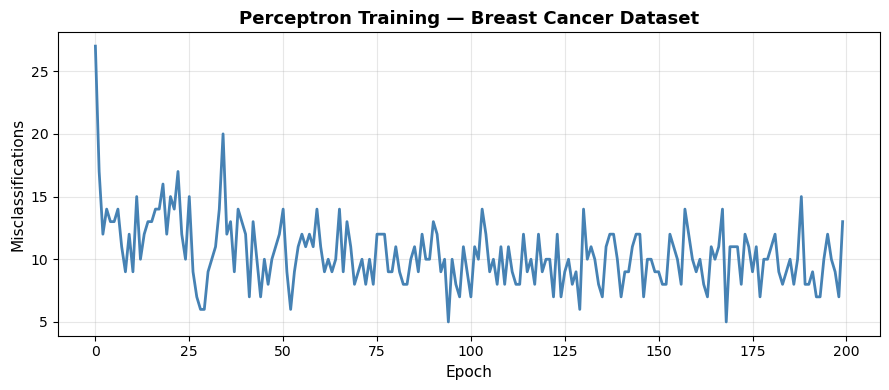

In [6]:
data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_s = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_s, y, test_size=0.2, random_state=42)

p_bc = Perceptron(learning_rate=0.01, n_iterations=200)
p_bc.fit(X_train, y_train)
y_pred_bc = p_bc.predict(X_test)

print(f"Breast Cancer — Test Accuracy: {accuracy_score(y_test, y_pred_bc):.4f}")

cm = confusion_matrix(y_test, y_pred_bc)
print(f"Confusion Matrix:\n{cm}")

# Plot errors per epoch
plt.figure(figsize=(9, 4))
plt.plot(p_bc.errors_, color='steelblue', linewidth=2)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Misclassifications', fontsize=11)
plt.title('Perceptron Training — Breast Cancer Dataset', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/perceptron_cancer.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary

| Property | Value |
|---|---|
| Type | Single neuron, online learning |
| Activation | Step function |
| Update rule | Hebbian / delta rule |
| Convergence | Guaranteed only for linearly separable data |
| Limitation | Cannot solve XOR or non-linear problems |

**Key Takeaways:**
- The Perceptron is the **building block of all neural networks**
- It only works for **linearly separable** data
- Stacking perceptrons with non-linear activations (MLP) overcomes this limitation
- Feature scaling is important for stable convergence